In [1]:
import torch    
import json 
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import LPM, standard, LKV
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load model

In [2]:
name = "underdamped_k12"

overdamped_path = f"/home/jovyan/PTL-PINNs/ptlpinns/models/train/{name}"
overdamped_name = f"model_{name}.pth"
overdamped_model, training_log = model.load_model(overdamped_path, overdamped_name)

12 True True True 1.0 16 [128, 128, 256]


In [3]:
# from ptlpinns.models.model import Multihead_model_fourier
# overdamped_model = Multihead_model_fourier(
#         k=training_log['k'],
#         bias=training_log['bias'],
#         use_sine=False,
#         use_fourier=False,
#         scale=training_log['scale'],
#         n_frequencies=training_log['n_frequencies'],
#         HIDDEN_LAYERS=training_log['hidden_layers'],)

### Problem definition

In [4]:
N = 512
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], N)

### Compute latent representations

In [5]:
H_dict = transfer.compute_H_dict(overdamped_model, N=N, bias=True, t_span=t_span)

### Transfer parameters

In [6]:
w_list_transfer = [1, 1, 1]
zeta_list = [0.25, 0.5, 0.7]

def forcing(numpy=False):
    if not numpy:
        def force(t):
            return torch.stack((torch.zeros_like(t), torch.cos(t)), dim=1)
    else:
        def force(t):
            return np.stack((np.zeros_like(t), np.cos(t)), axis=1)
    return force

forcing_list = [forcing(True), forcing(True), forcing(True), forcing(True), forcing(True)]

forcing_1D = lambda t: np.cos(t)
ic_list = [[1, 0], [1, 0], [1, 0]]
epsilon_list = [0.5, 0.5, 0.5]
p_list = [6]
q = [(3, 1)]

### Numerical solver

In [7]:
numerical_list = []

for zeta in zeta_list:
    ode = equations.ode_oscillator_1D(w_0=w_list_transfer[0], zeta=zeta, forcing_1D=forcing_1D, q=q, epsilon=epsilon_list[0])
    numerical_list.append(numerical.solve_ode_equation(ode, (t_eval[0], t_eval[-1]), t_eval, ic_list[0]))

### PINN

In [8]:
NN_TL_solution, perturbation_solution, _ = transfer.compute_perturbation_solution(w_list_transfer, zeta_list, epsilon_list, p_list, ic_list, forcing_list, H_dict, t_eval, training_log, all_p=True, comp_time=False, solver="standard", power=q)
NN_TL_solution = NN_TL_solution.squeeze()

In [9]:
NN_TL_solution.shape

(512, 3, 2)

In [10]:
PINN_solution = []

for perturbation_zeta in perturbation_solution:

    perturbation = []
    for perturbation_order in perturbation_zeta:

        perturbation.append(perturbation_order[:, 0])

    PINN_solution.append(standard.calculate_general_series(perturbation, epsilon_list[0]))

zeta: 0.25, order: 0, mean error absolute: 0.4786307334511663
zeta: 0.25, order: 1, mean error absolute: 0.6510273989089085
zeta: 0.25, order: 2, mean error absolute: 0.7777222263269414
zeta: 0.25, order: 3, mean error absolute: 1.0346767831366026
zeta: 0.25, order: 4, mean error absolute: 2.1774443352716966
zeta: 0.25, order: 5, mean error absolute: 4.441707281692557


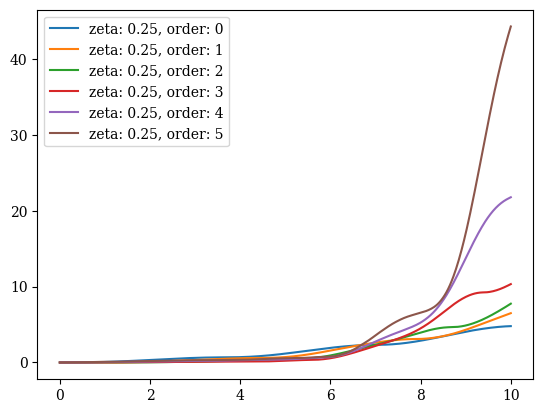

zeta: 0.5, order: 0, mean error absolute: 0.17869212549662383
zeta: 0.5, order: 1, mean error absolute: 0.0858662464203033
zeta: 0.5, order: 2, mean error absolute: 0.04030161518621113
zeta: 0.5, order: 3, mean error absolute: 0.03620189781505499
zeta: 0.5, order: 4, mean error absolute: 0.02325185001061929
zeta: 0.5, order: 5, mean error absolute: 0.01947520079393883


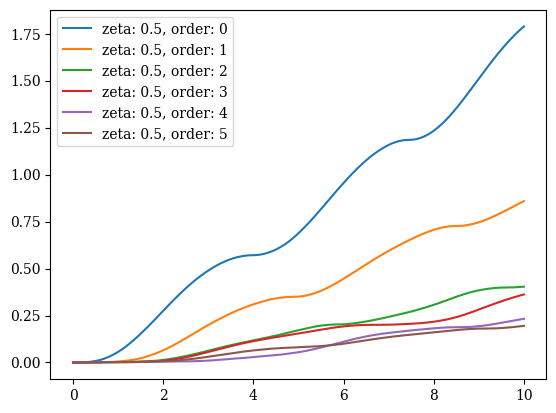

zeta: 0.7, order: 0, mean error absolute: 0.09523719635727546
zeta: 0.7, order: 1, mean error absolute: 0.039603617049276695
zeta: 0.7, order: 2, mean error absolute: 0.019055389262172914
zeta: 0.7, order: 3, mean error absolute: 0.01555090303243194
zeta: 0.7, order: 4, mean error absolute: 0.011011378581554203
zeta: 0.7, order: 5, mean error absolute: 0.009812712130512064


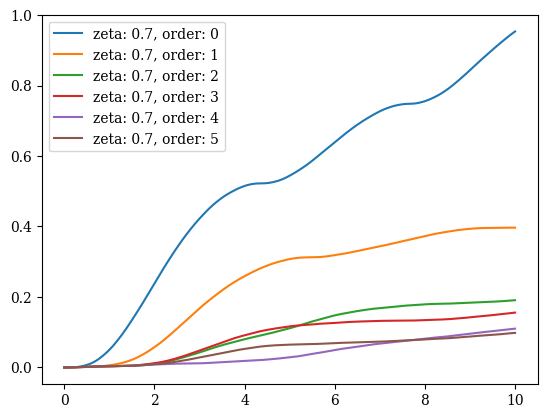

In [11]:
standard.plot_error_by_order(t_eval, PINN_solution, numerical_list, p_list, zeta_list, "zeta")

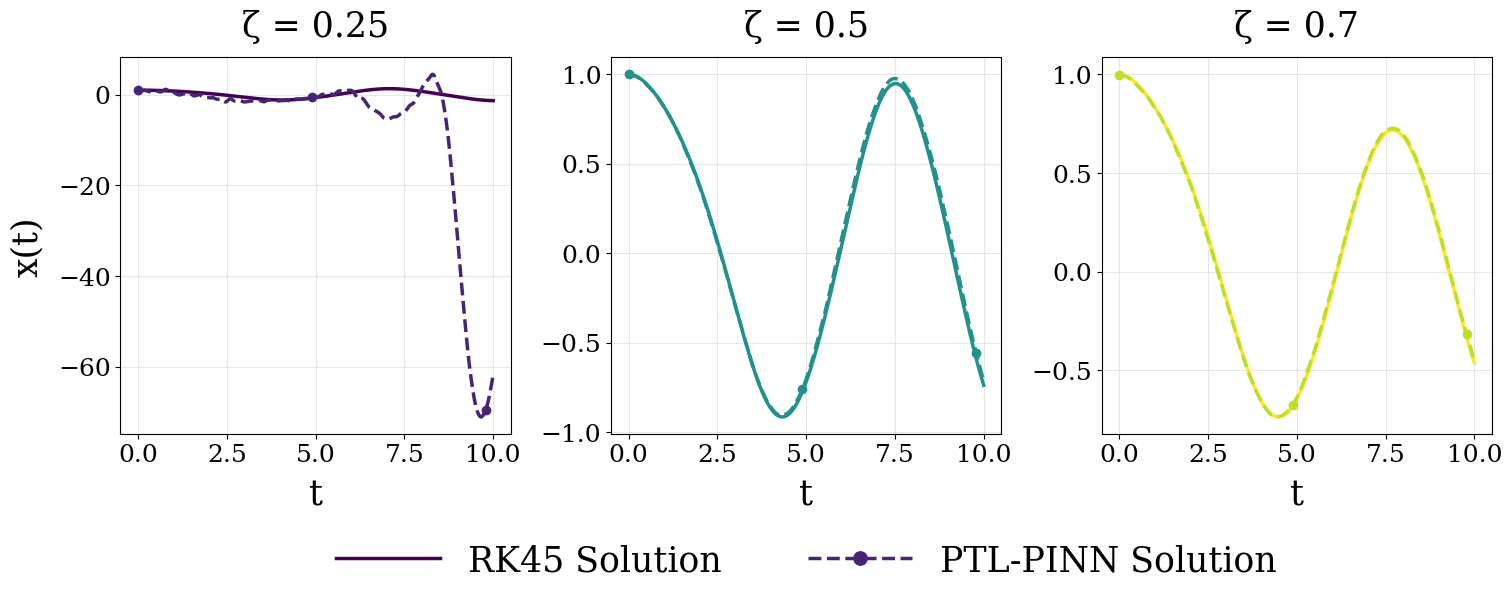

In [12]:
standard.plot_compare_multiple_zeta(t_eval, zeta_list, numerical_list, NN_TL_solution)


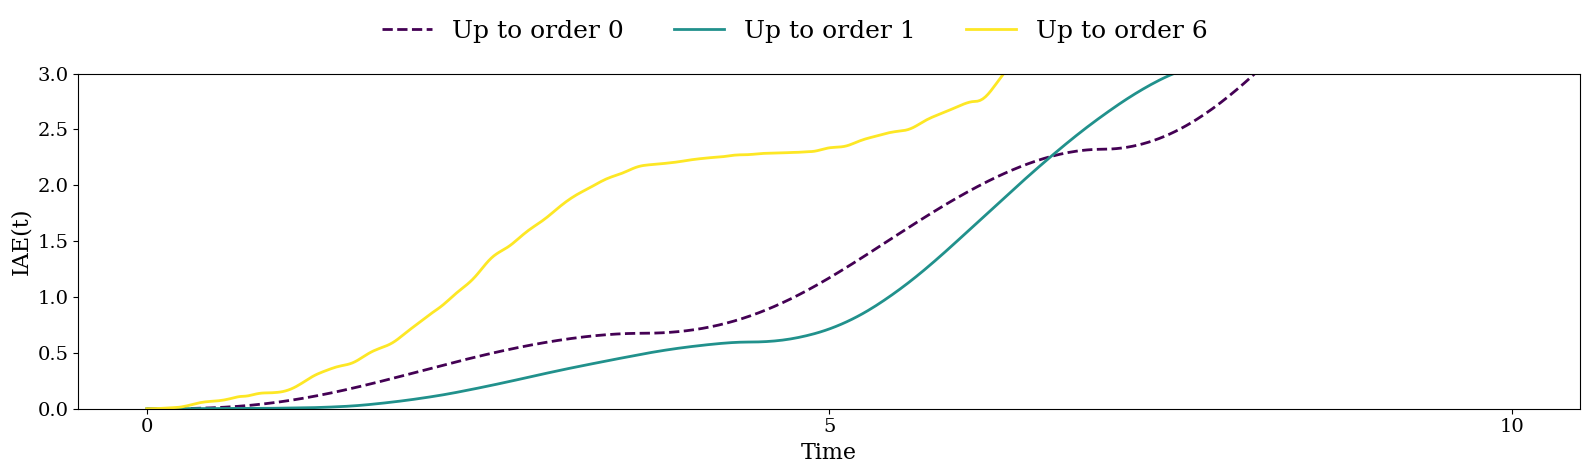

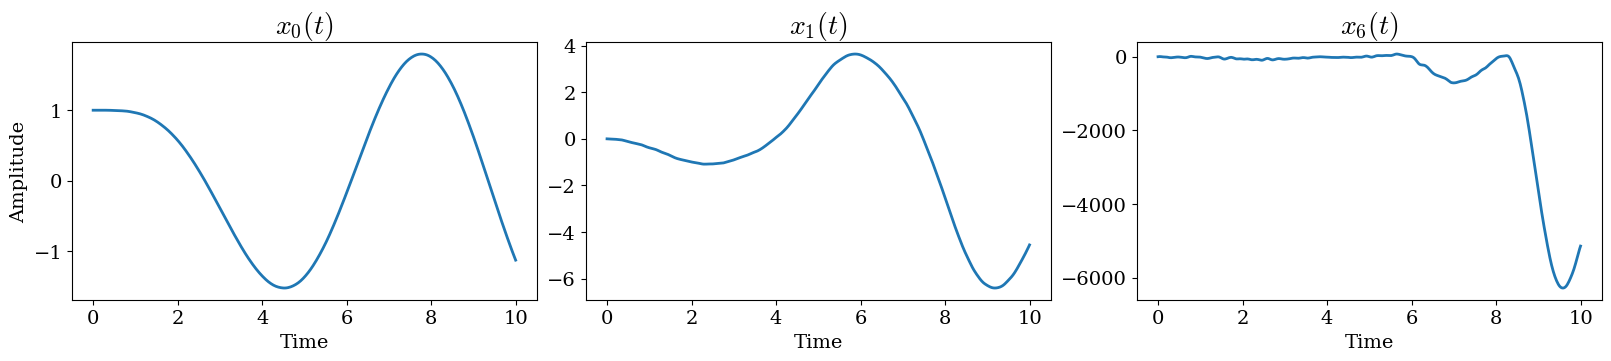

In [13]:
perturbation_solution_show = perturbation_solution[0]

PINN_x_solution = [perturbation_solution_show[i][:, 0] for i in range(len(perturbation_solution_show))]
PINN_x_solution = standard.calculate_general_series(PINN_x_solution, epsilon=epsilon_list[0])

standard.plot_IAE_and_subplots(PINN_x_solution, numerical_list[0], perturbation_solution_show, t_eval, selected_orders=[0, 1, 6], ylim=(0, 3))

/tmp/ipykernel_27847/3129563047.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", 3)


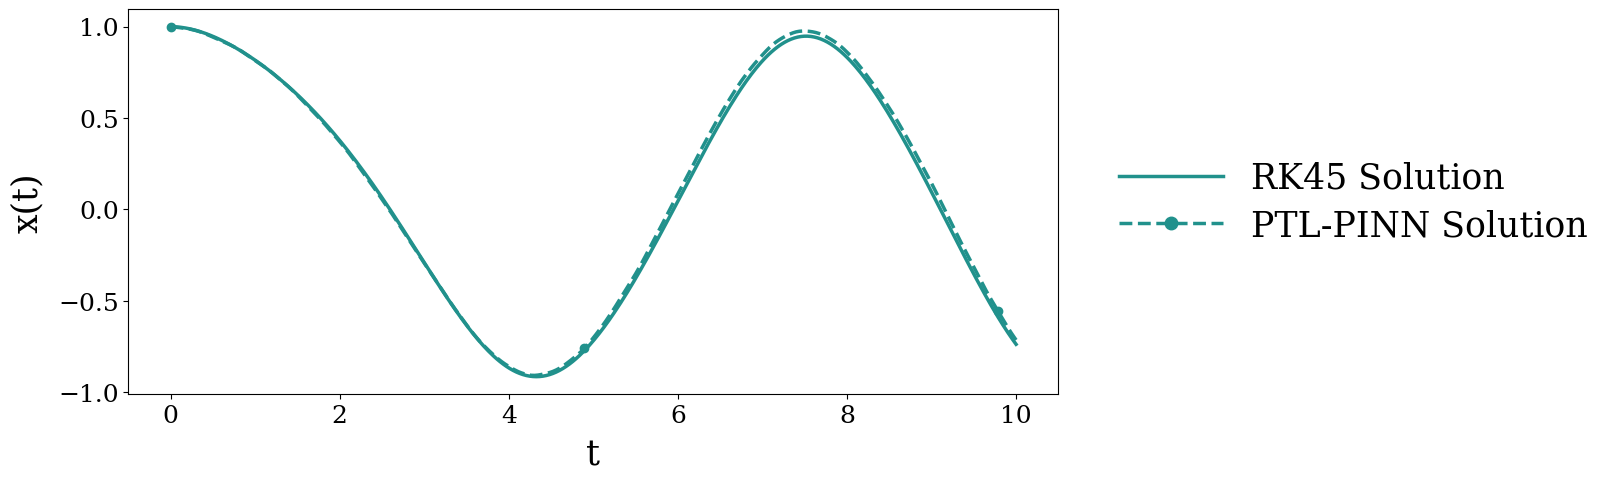

In [14]:
import matplotlib.cm as cm

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
})

def plot_solution(t_eval, y_num, y_nn, i = 0):
    title_fs  = 25
    label_fs  = 25
    tick_fs   = 18
    legend_fs = 25
    cmap = cm.get_cmap("viridis", 3)

    fig, ax = plt.subplots(figsize=(12, 5))

    base_color = cmap(i / 2)
    rk_color   = base_color
    pinn_color = cm.viridis(0.1 + 0.8 * i / 2)

    ax.plot(t_eval, y_num,
            label="RK45 Solution",
            color=rk_color, linewidth=2.5)

    ax.plot(t_eval, y_nn,
            label="PTL-PINN Solution",
            color=pinn_color, linewidth=2.5,
            linestyle="--", marker="o", markevery=250)

    ax.set_xlabel("t", fontsize=label_fs, labelpad=8)
    ax.set_ylabel("x(t)", fontsize=label_fs, labelpad=10)

    ax.tick_params(axis='both', labelsize=tick_fs)

    # Set y-limits with padding
    y_min = min(np.min(y_num), np.min(y_nn))
    y_max = max(np.max(y_num), np.max(y_nn))
    pad = 0.05 * max(1e-12, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # (x, y): anchor the legend outside the right border
    fontsize=legend_fs,
    frameon=False,
    handlelength=3.0,
    markerscale=1.5,
    labelspacing=0.4,
    borderaxespad=0.8)
    plt.show()

plot_solution(t_eval, numerical_list[1][0, :], NN_TL_solution[:, 1, 0], i = 1)

In [15]:
ode_high_acc = equations.ode_oscillator_1D(w_0=1, zeta=0.5, forcing_1D=forcing_1D, q=q, epsilon=epsilon_list[0])
dt = (t_eval[1] - t_eval[0])/100
t_eval_high_acc = np.linspace(t_span[0], t_span[1], (t_eval.size - 1)*100 + 1)
num_high_acc = numerical.solve_ode_equation(ode_high_acc, (t_eval_high_acc[0], t_eval_high_acc[-1]), t_eval_high_acc, ic_list[0])[0, :]

In [16]:
error = []
for i in range(p_list[0]):
    error.append(np.mean(np.abs(PINN_solution[1][i] - num_high_acc[::100])))

In [ ]:
error

[np.float64(0.17869212549662408),
 np.float64(0.0858662464203031),
 np.float64(0.04030161518621109),
 np.float64(0.03620189781505513),
 np.float64(0.023251850010619166),
 np.float64(0.01947520079393887)]

## Hyperparameter sweep — MAE vs perturbation order across underdamping regimes

The "actual model" used in this notebook is the pretrained PINN
`underdamped_k12` (sine first layer + Fourier features, multi-head).
Following the LV / overdamped sweeps, we compare it against a family of
random tanh PINNs with no Fourier features and varying hidden-layer
matrix size $W \in \{32, 64, 128, 256, 512\}$
(`Multihead_model_fourier(use_sine=False, use_fourier=False, HIDDEN_LAYERS=[W, W, 2W])`).

The sweep is repeated for three underdamping regimes
($\zeta \in \{0.25, 0.5, 0.7\}$ from the existing `zeta_list`) with the
same $\varepsilon = 0.5$, cubic nonlinearity $q = [(3, 1)]$ and forcing
$f(t) = \cos t$ used in the standard-perturbation pipeline above.
For each $\zeta$ we plot the MAE of the cumulative position estimate
against a high-resolution Radau reference at every perturbation order
$p = 0,\dots,p_{\max}$.

In [ ]:
from ptlpinns.models.model import Multihead_model_fourier


def _make_pretrained_dict():
    """Reuse the H_dict already built from the pretrained `underdamped_k12`."""
    return H_dict, training_log


def _make_tanh_dict(hidden_layers, seed=0):
    """Random tanh PINN with no Fourier features and the requested width."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    rand_model = Multihead_model_fourier(
        k=training_log["k"],
        bias=training_log["bias"],
        use_sine=False,
        use_fourier=False,
        scale=1.0,
        n_frequencies=16,
        HIDDEN_LAYERS=hidden_layers,
    )
    return transfer.compute_H_dict(rand_model, N=N, bias=True, t_span=t_span), training_log


# Compare the actual model (pretrained underdamped_k12) against the same
# tanh-no-Fourier family at several widths.
sweep_configs = [
    ("Pretrained $H$ (underdamped_k12, actual model)",
        _make_pretrained_dict),
    ("Random $H$ (tanh, no Fourier, W=32)",
        lambda: _make_tanh_dict([32,  32,  64])),
    ("Random $H$ (tanh, no Fourier, W=64)",
        lambda: _make_tanh_dict([64,  64,  128])),
    ("Random $H$ (tanh, no Fourier, W=128)",
        lambda: _make_tanh_dict([128, 128, 256])),
    ("Random $H$ (tanh, no Fourier, W=256)",
        lambda: _make_tanh_dict([256, 256, 512])),
    ("Random $H$ (tanh, no Fourier, W=512)",
        lambda: _make_tanh_dict([512, 512, 1024])),
]

# Three underdamping regimes from the existing zeta_list.
regime_zetas = list(zeta_list)   # [0.25, 0.5, 0.7]
p_max        = p_list[0]         # 6

[label for label, _ in sweep_configs], regime_zetas, p_max

(['Pretrained $H$ (underdamped_k12, actual model)',
  'Random $H$ (tanh, no Fourier, W=32)',
  'Random $H$ (tanh, no Fourier, W=64)',
  'Random $H$ (tanh, no Fourier, W=128)',
  'Random $H$ (tanh, no Fourier, W=256)',
  'Random $H$ (tanh, no Fourier, W=512)'],
 [0.25, 0.5, 0.7],
 6)

In [ ]:
errors_by_regime = {}

for zeta in regime_zetas:
    ode_z = equations.ode_oscillator_1D(
        w_0=w_list_transfer[0], zeta=zeta, forcing_1D=forcing_1D,
        q=q, epsilon=epsilon_list[0],
    )

    errs_this_regime = {}
    print(f"\n=== ζ = {zeta} ===")

    for label, factory in sweep_configs:
        H_cfg, tlog = factory()
        cond_H = np.linalg.cond(H_cfg["H"])

        err = standard.compute_error_per_order_standard(
            H_dict=H_cfg,
            training_log=tlog,
            w_0=w_list_transfer[0],
            zeta=zeta,
            epsilon=epsilon_list[0],
            p_max=p_max,
            ic=ic_list[0],
            forcing_function=forcing_list[0],
            q=q,
            ode=ode_z,
            t_eval=t_eval,
        )

        legend_label = (
            f"{label}  [$\\kappa(H)$={cond_H:.1e}, "
            f"MAE@$p$={len(err) - 1}: {err[-1]:.2e}]"
        )
        errs_this_regime[legend_label] = err
        print(f"  {label:<48s}  MAE @ p={len(err) - 1}: {err[-1]:.3e}  |  cond(H)={cond_H:.2e}")

    errors_by_regime[zeta] = errs_this_regime

list(errors_by_regime.keys())


=== ζ = 0.25 ===
  Pretrained $H$ (underdamped_k12, actual model)    MAE @ p=6: 7.779e+00  |  cond(H)=5.16e+04


  Random $H$ (tanh, no Fourier, W=32)               MAE @ p=6: 9.471e+00  |  cond(H)=6.37e+05


  Random $H$ (tanh, no Fourier, W=64)               MAE @ p=6: 7.735e+00  |  cond(H)=1.01e+09


  Random $H$ (tanh, no Fourier, W=128)              MAE @ p=6: 7.705e+00  |  cond(H)=4.87e+15


  Random $H$ (tanh, no Fourier, W=256)              MAE @ p=6: 7.739e+00  |  cond(H)=2.07e+16


...

  Random $H$ (tanh, no Fourier, W=64)               MAE @ p=6: 3.337e-03  |  cond(H)=1.01e+09


  Random $H$ (tanh, no Fourier, W=128)              MAE @ p=6: 3.184e-03  |  cond(H)=4.87e+15


  Random $H$ (tanh, no Fourier, W=256)              MAE @ p=6: 3.067e-03  |  cond(H)=2.07e+16


  Random $H$ (tanh, no Fourier, W=512)              MAE @ p=6: 3.183e-03  |  cond(H)=3.32e+16


[0.25, 0.5, 0.7]

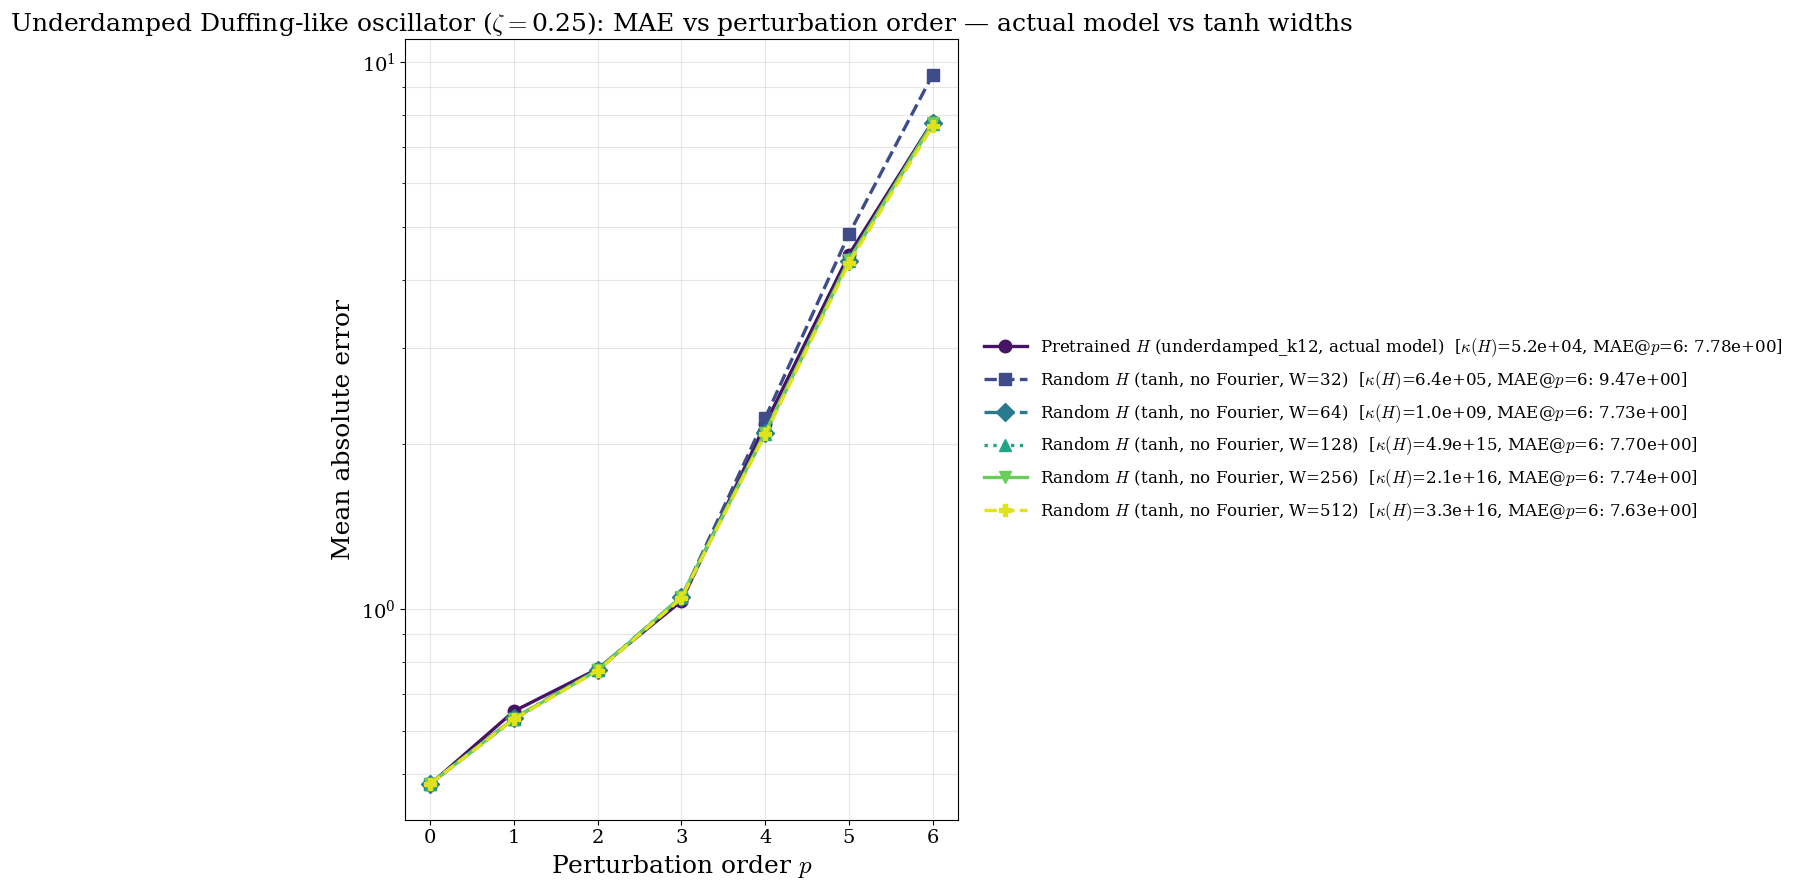

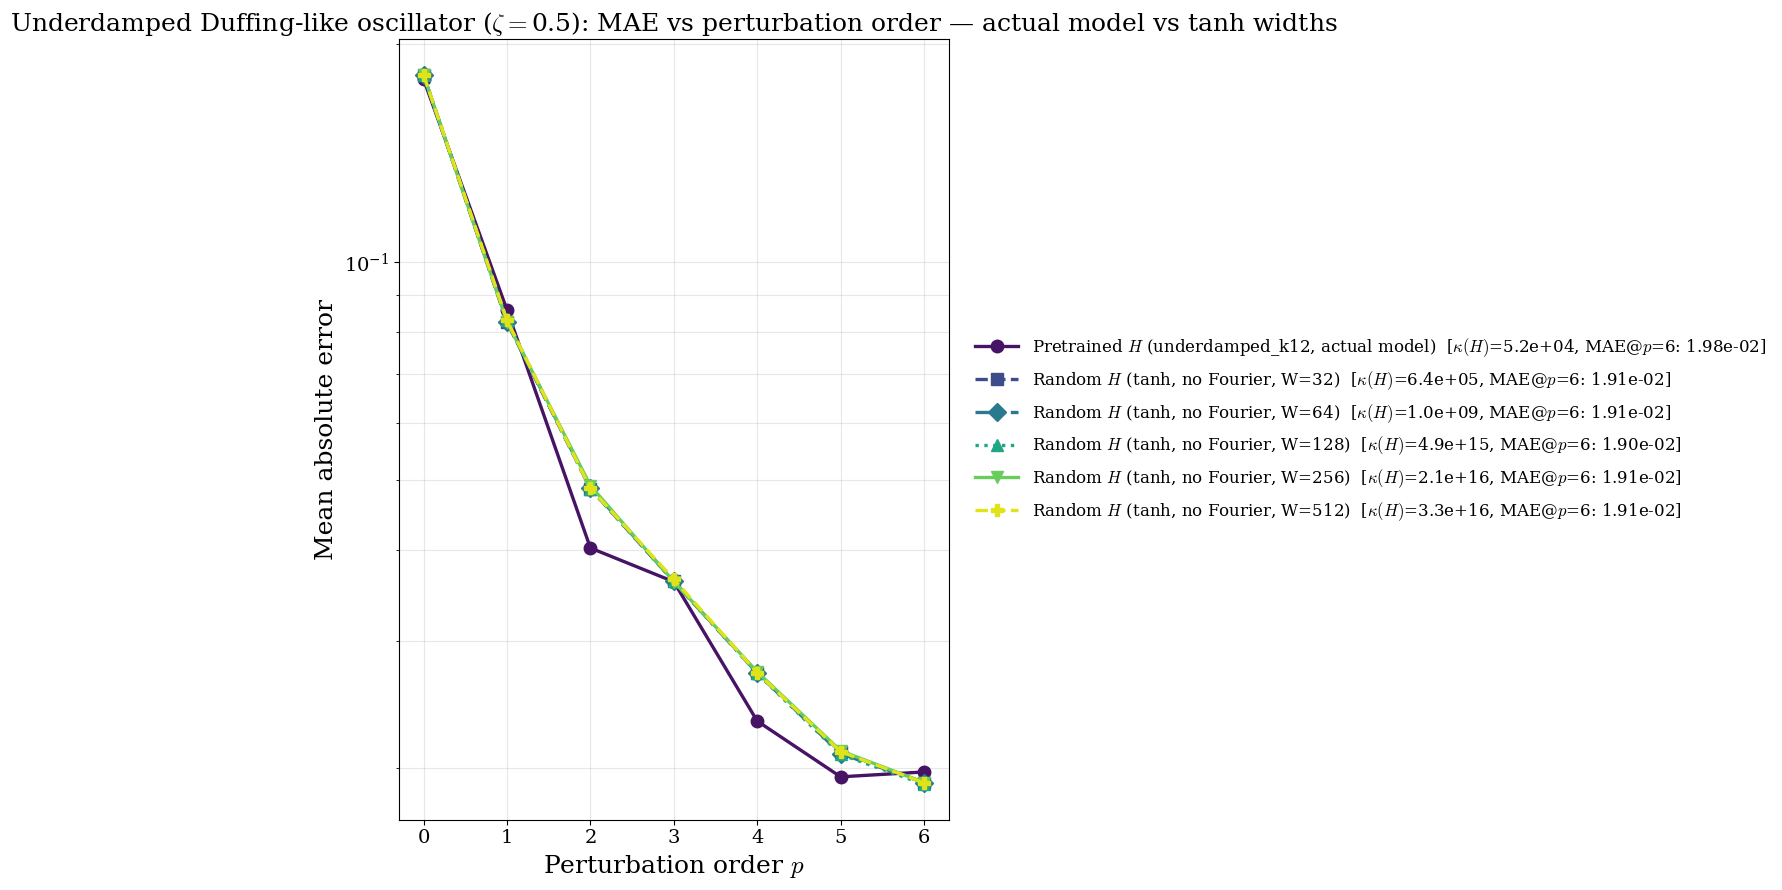

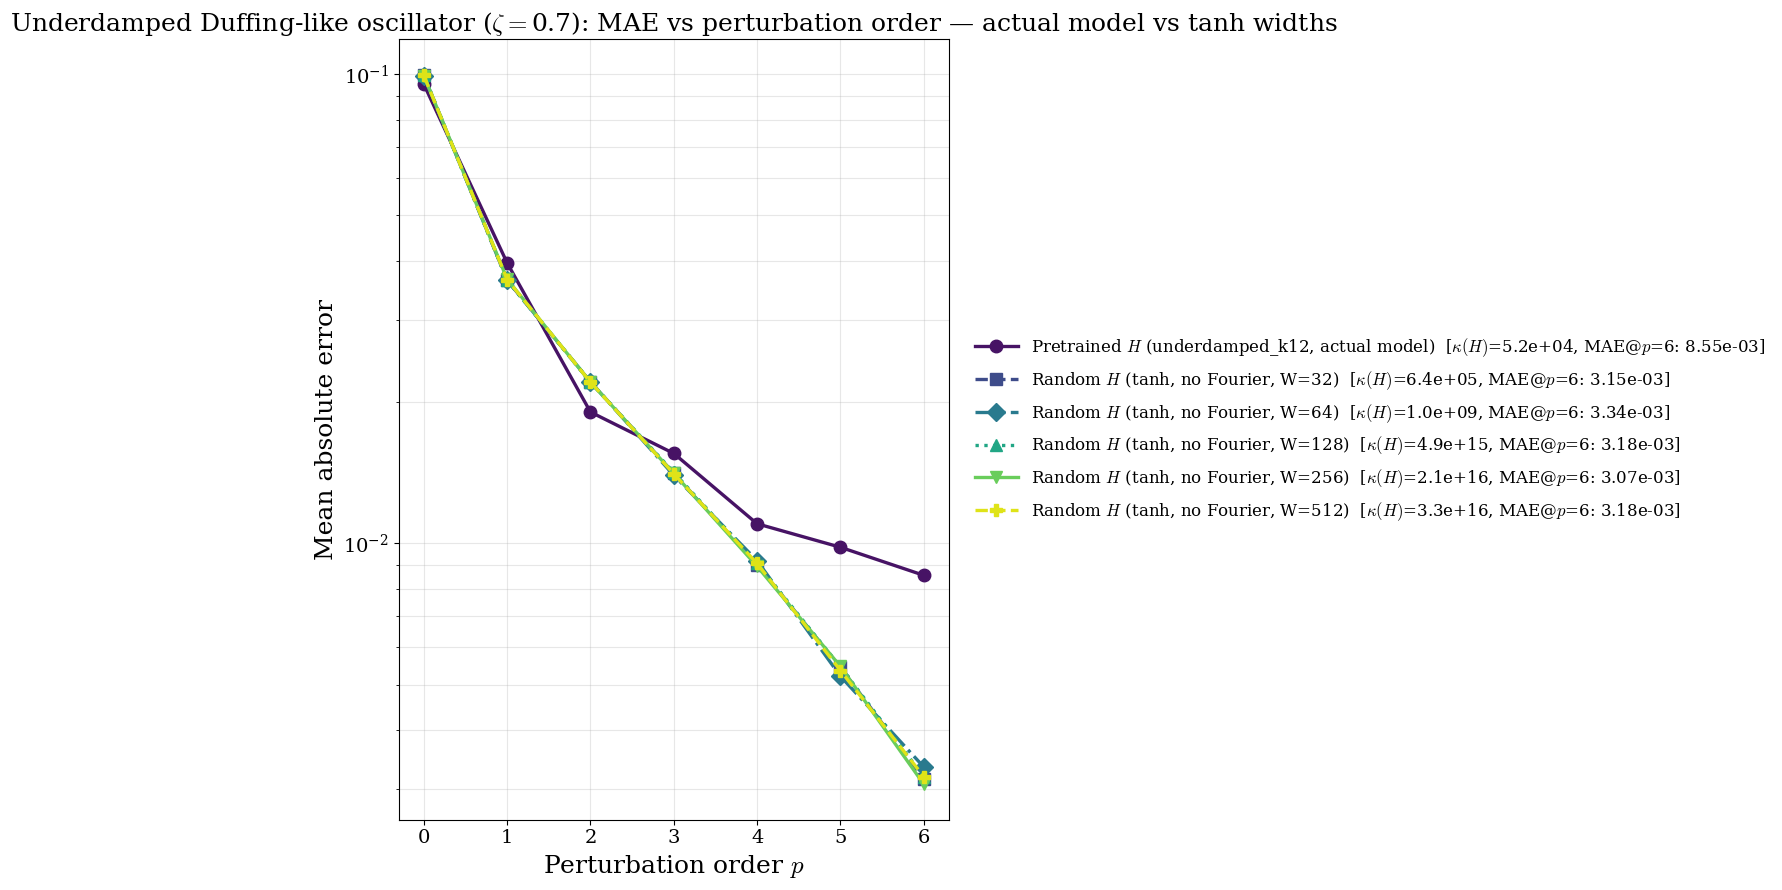

In [ ]:
for zeta, errs in errors_by_regime.items():
    LKV.plot_mae_vs_order(
        errs,
        title=(
            r"Underdamped Duffing-like oscillator ($\zeta=$" + f"{zeta}" + r"): "
            r"MAE vs perturbation order — actual model vs tanh widths"
        ),
    )